# HR Analytics AI System
## Notebook 7: Insights and HR Recommendations

In this notebook, we will utilize the results from all previous notebooks
to generate actionable insights and recommend HR strategies.

The analysis covers the following areas:

1. Identifying High-Risk Employees
2. Cluster-Based HR Recommendations
3. Department-Level Insights
4. Key Attrition Risk Factors
5. Strategic HR Recommendations

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import RandomForestClassificationModel
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Initialize Spark Session and Load Data

In [2]:
spark = SparkSession.builder \
    .appName("HR Analytics - Insights") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# Load engineered data
df = spark.read.parquet(
    r"C:\HR-Analytics-AI-System\data\hr_data_engineered.parquet"
)

# Load original data for categorical labels
df_original = spark.read.parquet(
    r"C:\HR-Analytics-AI-System\data\hr_data.parquet"
)

print("Data Loaded Successfully.")
print(f"Total Rows: {df.count()}")

Data Loaded Successfully.
Total Rows: 1470


### 2. Rebuild Clusters

We rebuild the K-Means clustering model using the same parameters
from Notebook 6 to assign cluster labels to each employee.

In [3]:
cluster_features = [
    "Age", "MonthlyIncome", "JobLevel",
    "TotalWorkingYears", "YearsAtCompany", "RiskScore"
]

assembler = VectorAssembler(
    inputCols=cluster_features,
    outputCol="features_raw"
)

df_assembled = assembler.transform(df)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True,
    withMean=True
)

df_scaled = scaler.fit(df_assembled).transform(df_assembled)

kmeans = KMeans(
    featuresCol="features_scaled",
    predictionCol="cluster",
    k=3,
    seed=42
)

kmeans_model = kmeans.fit(df_scaled)
df_clustered = kmeans_model.transform(df_scaled)

cluster_labels = {
    0: "Mid-Career Stable",
    1: "Young High-Risk",
    2: "Senior High-Income"
}

print("Clusters rebuilt successfully.")
print("-" * 40)
df_clustered.groupBy("cluster").count().orderBy("cluster").show()

Clusters rebuilt successfully.
----------------------------------------
+-------+-----+
|cluster|count|
+-------+-----+
|      0|  628|
|      1|  624|
|      2|  218|
+-------+-----+



### 3. Identifying High-Risk Employees

We identify employees with the highest attrition risk based on their RiskScore.
Employees with a RiskScore above 0.6 are considered high-risk
and require immediate HR intervention.

In [4]:
high_risk = df_clustered.filter(F.col("RiskScore") >= 0.6) \
    .select(
        "Age", "MonthlyIncome", "JobLevel",
        "TotalWorkingYears", "YearsAtCompany",
        "OverTime_encoded", "EngagementScore",
        "SatisfactionScore", "RiskScore", "cluster"
    ).orderBy("RiskScore", ascending=False)

total_high_risk = high_risk.count()
total_employees = df_clustered.count()
high_risk_pct = (total_high_risk / total_employees * 100)

print("High-Risk Employee Analysis:")
print("=" * 40)
print(f"Total Employees:      {total_employees}")
print(f"High-Risk Employees:  {total_high_risk}")
print(f"High-Risk Percentage: {high_risk_pct:.1f}%")
print("=" * 40)
print("\nTop 10 Highest Risk Employees:")
high_risk.show(10)

print("\nHigh-Risk Employees by Cluster:")
high_risk.groupBy("cluster").count().orderBy("cluster").show()

High-Risk Employee Analysis:
Total Employees:      1470
High-Risk Employees:  194
High-Risk Percentage: 13.2%

Top 10 Highest Risk Employees:
+---+-------------+--------+-----------------+--------------+----------------+---------------+-----------------+---------+-------+
|Age|MonthlyIncome|JobLevel|TotalWorkingYears|YearsAtCompany|OverTime_encoded|EngagementScore|SatisfactionScore|RiskScore|cluster|
+---+-------------+--------+-----------------+--------------+----------------+---------------+-----------------+---------+-------+
| 20|         2600|       1|                1|             1|             1.0|           1.33|             2.25|   0.8044|      1|
| 59|         2670|       1|               12|             1|             1.0|            2.0|             1.75|   0.7875|      1|
| 33|         2313|       1|                5|             2|             1.0|            2.0|              2.0|    0.775|      1|
| 31|         2321|       1|                4|             3|           

### High-Risk Employee Analysis Results

The analysis identified 194 high-risk employees (13.2% of total workforce)
with a RiskScore above 0.6 who require immediate HR intervention.

**Key observations from the top 10 highest risk employees:**
- All top 10 high-risk employees work overtime (OverTime = 1.0)
- All have Job Level 1, indicating entry-level positions
- Monthly incomes range from $1,859 to $6,134
- Engagement scores are consistently low, ranging from 1.33 to 2.0
- Years at company range from 1 to 4, indicating recent hires

**High-Risk Distribution by Cluster:**
- Cluster 1 - Young High-Risk: 169 employees (87.1% of all high-risk)
- Cluster 0 - Mid-Career Stable: 20 employees (10.3% of all high-risk)
- Cluster 2 - Senior High-Income: 5 employees (2.6% of all high-risk)

This confirms that the Young High-Risk cluster is the most critical group,
containing the vast majority of employees at risk of leaving the company.

### 4. High-Risk Employees Visualization

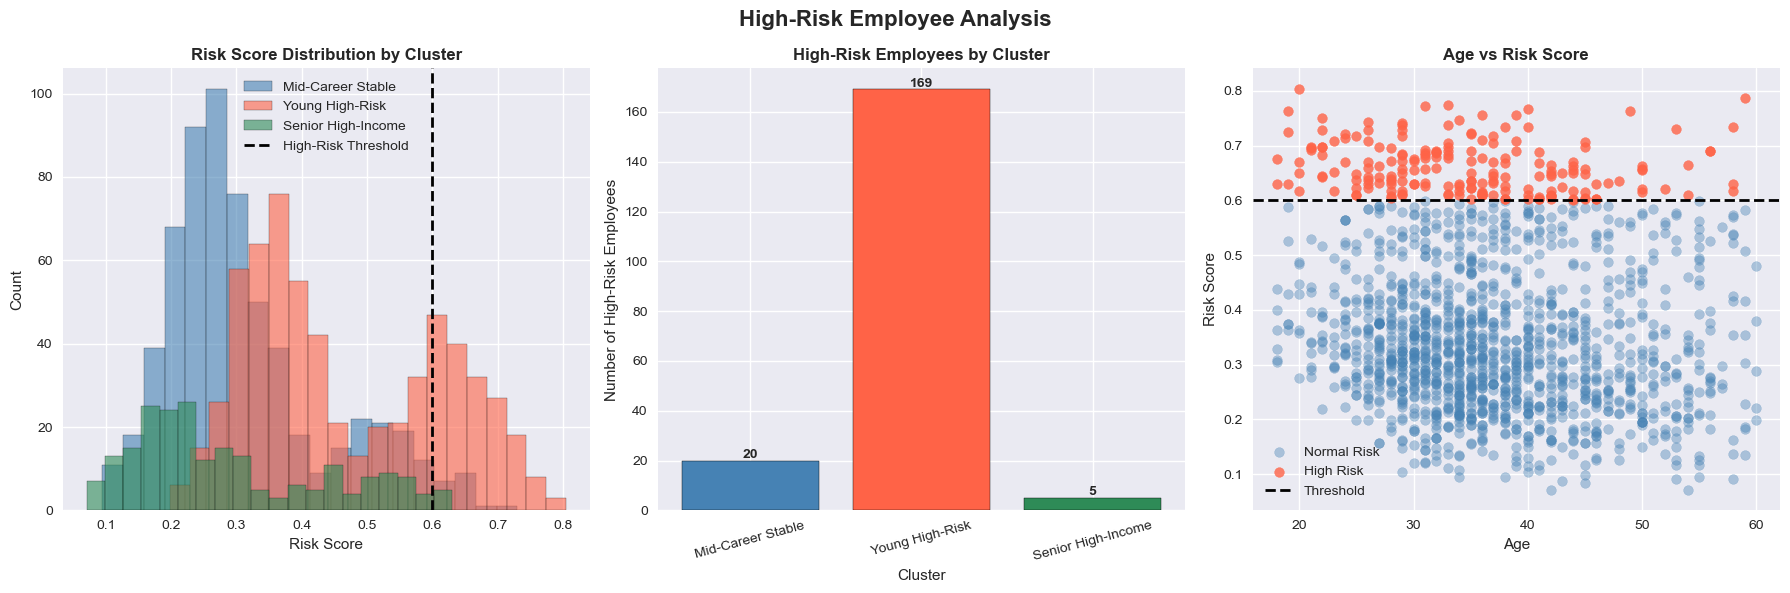

In [5]:
high_risk_pdf = high_risk.toPandas()
cluster_pdf = df_clustered.select(
    "Age", "MonthlyIncome", "RiskScore", "cluster"
).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Risk Score Distribution by Cluster
colors = {0: "steelblue", 1: "tomato", 2: "seagreen"}
labels = {0: "Mid-Career Stable", 1: "Young High-Risk", 2: "Senior High-Income"}

for cluster in [0, 1, 2]:
    subset = cluster_pdf[cluster_pdf["cluster"] == cluster]["RiskScore"]
    axes[0].hist(subset, bins=20, alpha=0.6,
                 color=colors[cluster], label=labels[cluster], edgecolor="black")
axes[0].axvline(x=0.6, color="black", linestyle="--", linewidth=2, label="High-Risk Threshold")
axes[0].set_title("Risk Score Distribution by Cluster", fontweight="bold")
axes[0].set_xlabel("Risk Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# 2. High-Risk by Cluster
hr_cluster = high_risk_pdf["cluster"].value_counts().sort_index()
axes[1].bar([labels[i] for i in hr_cluster.index],
            hr_cluster.values,
            color=[colors[i] for i in hr_cluster.index],
            edgecolor="black")
axes[1].set_title("High-Risk Employees by Cluster", fontweight="bold")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Number of High-Risk Employees")
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(hr_cluster.values):
    axes[1].text(i, v + 1, str(v), ha="center", fontweight="bold")

# 3. Age vs RiskScore
axes[2].scatter(
    cluster_pdf[cluster_pdf["RiskScore"] < 0.6]["Age"],
    cluster_pdf[cluster_pdf["RiskScore"] < 0.6]["RiskScore"],
    color="steelblue", alpha=0.4, label="Normal Risk"
)
axes[2].scatter(
    high_risk_pdf["Age"],
    high_risk_pdf["RiskScore"],
    color="tomato", alpha=0.8, label="High Risk"
)
axes[2].axhline(y=0.6, color="black", linestyle="--", linewidth=2, label="Threshold")
axes[2].set_title("Age vs Risk Score", fontweight="bold")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Risk Score")
axes[2].legend()

plt.suptitle("High-Risk Employee Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\high_risk_analysis.png", dpi=150)
plt.show()

### 5. HR Recommendations by Cluster

Based on the clustering analysis and risk scores,
we provide targeted HR strategies for each employee segment.

In [6]:
cluster_summary = df_clustered.groupBy("cluster").agg(
    F.count("*").alias("Total Employees"),
    F.round(F.avg("RiskScore"), 3).alias("Avg Risk Score"),
    F.round(F.avg("MonthlyIncome"), 0).alias("Avg Income"),
    F.round(F.avg("Age"), 1).alias("Avg Age"),
    F.round(F.avg("TotalWorkingYears"), 1).alias("Avg Experience"),
    F.round(F.avg("EngagementScore"), 2).alias("Avg Engagement"),
    F.round(F.avg("SatisfactionScore"), 2).alias("Avg Satisfaction"),
    F.round(F.avg("OverTime_encoded"), 2).alias("Overtime Rate")
).orderBy("cluster").toPandas()

print("HR Recommendations by Cluster:")
print("=" * 60)

recommendations = {
    0: {
        "name": "Mid-Career Stable Employees",
        "strategies": [
            "Provide clear career advancement pathways and promotion opportunities",
            "Offer leadership development and mentorship programs",
            "Implement flexible working arrangements to maintain work-life balance",
            "Conduct regular performance reviews with constructive feedback",
            "Recognize and reward long-term commitment and contributions"
        ]
    },
    1: {
        "name": "Young High-Risk Employees",
        "strategies": [
            "Immediately review and adjust overtime policies for this group",
            "Implement competitive salary reviews and market-rate adjustments",
            "Create structured onboarding and mentorship programs",
            "Offer clear career growth roadmaps with achievable milestones",
            "Provide engagement programs such as team building and social events",
            "Conduct regular one-on-one check-ins to address concerns early"
        ]
    },
    2: {
        "name": "Senior High-Income Employees",
        "strategies": [
            "Offer executive retention packages and long-term incentives",
            "Involve senior employees in strategic decision-making",
            "Provide knowledge transfer programs to preserve institutional knowledge",
            "Offer flexible retirement transition plans",
            "Recognize their contributions through awards and public recognition"
        ]
    }
}

for cluster_id, info in recommendations.items():
    row = cluster_summary[cluster_summary["cluster"] == cluster_id].iloc[0]
    print(f"\nCluster {cluster_id}: {info['name']}")
    print(f"  Total Employees:  {int(row['Total Employees'])}")
    print(f"  Avg Risk Score:   {row['Avg Risk Score']}")
    print(f"  Avg Income:       ${int(row['Avg Income']):,}")
    print(f"  Avg Age:          {row['Avg Age']} years")
    print(f"  Avg Experience:   {row['Avg Experience']} years")
    print(f"  Avg Engagement:   {row['Avg Engagement']}")
    print(f"  Overtime Rate:    {row['Overtime Rate']}")
    print(f"\n  Recommended Strategies:")
    for i, strategy in enumerate(info['strategies'], 1):
        print(f"  {i}. {strategy}")
    print("-" * 60)

HR Recommendations by Cluster:

Cluster 0: Mid-Career Stable Employees
  Total Employees:  628
  Avg Risk Score:   0.313
  Avg Income:       $6,436
  Avg Age:          38.8 years
  Avg Experience:   11.7 years
  Avg Engagement:   2.78
  Overtime Rate:    0.17

  Recommended Strategies:
  1. Provide clear career advancement pathways and promotion opportunities
  2. Offer leadership development and mentorship programs
  3. Implement flexible working arrangements to maintain work-life balance
  4. Conduct regular performance reviews with constructive feedback
  5. Recognize and reward long-term commitment and contributions
------------------------------------------------------------

Cluster 1: Young High-Risk Employees
  Total Employees:  624
  Avg Risk Score:   0.466
  Avg Income:       $3,405
  Avg Age:          31.2 years
  Avg Experience:   5.8 years
  Avg Engagement:   2.66
  Overtime Rate:    0.4

  Recommended Strategies:
  1. Immediately review and adjust overtime policies for th

### HR Recommendations Results

Based on the cluster analysis, the following targeted strategies are recommended:

**Cluster 0 - Mid-Career Stable Employees (628 employees, Avg Risk: 0.313):**
- These employees are relatively stable with moderate risk
- Focus on career advancement and leadership development
- Overtime rate is low at 17%, which helps maintain work-life balance
- Average engagement of 2.78 indicates room for improvement

**Cluster 1 - Young High-Risk Employees (624 employees, Avg Risk: 0.466):**
- This is the most critical group requiring immediate intervention
- Overtime rate is 40%, which is the highest among all clusters
- Low average income of $3,405 combined with high overtime is a major risk factor
- Average engagement of 2.66 is the lowest among all clusters
- Immediate salary reviews and overtime policy changes are strongly recommended

**Cluster 2 - Senior High-Income Employees (218 employees, Avg Risk: 0.289):**
- These employees have the lowest attrition risk
- High average income of $15,562 and 25.8 years of experience
- Focus on knowledge retention and succession planning
- Overtime rate of 28% should be monitored to prevent burnout

### 6. Key Attrition Risk Factors

Based on the complete analysis across all notebooks,
we summarize the most critical factors contributing to employee attrition.

In [7]:
# Overtime Impact
overtime_attrition = df.groupBy("OverTime_encoded").agg(
    F.count("*").alias("Total"),
    F.round(F.avg("Attrition_encoded") * 100, 1).alias("Attrition Rate %")
).orderBy("OverTime_encoded").toPandas()

# Age Group Impact
df_age = df.withColumn("AgeGroup",
    F.when(F.col("Age") < 25, "Under 25")
     .when((F.col("Age") >= 25) & (F.col("Age") < 35), "25-34")
     .when((F.col("Age") >= 35) & (F.col("Age") < 45), "35-44")
     .otherwise("45+")
)
age_attrition = df_age.groupBy("AgeGroup").agg(
    F.count("*").alias("Total"),
    F.round(F.avg("Attrition_encoded") * 100, 1).alias("Attrition Rate %")
).orderBy("AgeGroup").toPandas()

# Income Impact
df_income = df.withColumn("IncomeGroup",
    F.when(F.col("MonthlyIncome") <= 3000, "Low")
     .when((F.col("MonthlyIncome") > 3000) & (F.col("MonthlyIncome") <= 7000), "Medium")
     .otherwise("High")
)
income_attrition = df_income.groupBy("IncomeGroup").agg(
    F.count("*").alias("Total"),
    F.round(F.avg("Attrition_encoded") * 100, 1).alias("Attrition Rate %")
).orderBy("IncomeGroup").toPandas()

print("Key Attrition Risk Factors:")
print("=" * 40)
print("\n1. Overtime Impact:")
print(overtime_attrition.to_string(index=False))
print("\n2. Age Group Impact:")
print(age_attrition.to_string(index=False))
print("\n3. Income Group Impact:")
print(income_attrition.to_string(index=False))

Key Attrition Risk Factors:

1. Overtime Impact:
 OverTime_encoded  Total  Attrition Rate %
              0.0   1054              10.4
              1.0    416              30.5

2. Age Group Impact:
AgeGroup  Total  Attrition Rate %
   25-34    554              20.2
   35-44    505              10.1
     45+    314              11.5
Under 25     97              39.2

3. Income Group Impact:
IncomeGroup  Total  Attrition Rate %
       High    435              10.8
        Low    395              28.6
     Medium    640              12.0


### Key Attrition Risk Factors Results

The analysis confirms three major risk factors for employee attrition:

**1. Overtime:**
- Employees working overtime have an attrition rate of 30.5%
- Employees not working overtime have an attrition rate of only 10.4%
- Overtime increases attrition risk by nearly 3 times

**2. Age Group:**
- Under 25: highest attrition rate at 39.2% (97 employees)
- 25-34: second highest at 20.2% (554 employees)
- 35-44: lowest at 10.1% (505 employees)
- 45+: moderate at 11.5% (314 employees)

**3. Monthly Income:**
- Low income (below $3,000): attrition rate of 28.6% (395 employees)
- Medium income ($3,001-$7,000): attrition rate of 12.0% (640 employees)
- High income (above $7,000): attrition rate of 10.8% (435 employees)

These three factors combined explain the majority of attrition cases
and should be the primary focus of HR intervention strategies.

### 7. Strategic HR Recommendations

Based on all findings from the analysis, we present the following
company-wide HR strategies to reduce employee attrition.

In [9]:
print("=" * 60)
print("STRATEGIC HR RECOMMENDATIONS")
print("=" * 60)

strategies = {
    "1. Overtime Policy Reform": [
        "Cap overtime hours to a maximum of 10 hours per week",
        "Implement overtime compensation and time-off policies",
        "Monitor overtime patterns and flag employees exceeding limits",
        "Redistribute workload to reduce dependency on overtime"
    ],
    "2. Compensation Review": [
        "Conduct immediate salary benchmarking for low-income employees",
        "Implement performance-based salary increments",
        "Review compensation for employees earning below $3,000 per month",
        "Introduce stock options and benefits for entry-level employees"
    ],
    "3. Young Employee Retention": [
        "Create structured career development programs for under-35 employees",
        "Implement mentorship programs pairing juniors with senior employees",
        "Offer education assistance and professional certification support",
        "Establish clear promotion timelines and criteria"
    ],
    "4. Engagement Improvement": [
        "Launch quarterly employee satisfaction surveys",
        "Create cross-functional project opportunities",
        "Implement recognition and rewards programs",
        "Establish open-door communication policies with management"
    ],
    "5. High-Risk Employee Monitoring": [
        f"Immediately flag and monitor 194 identified high-risk employees",
        "Schedule monthly check-ins with high-risk employees",
        "Offer personalized retention packages for critical high-risk cases",
        "Track risk score changes monthly and update intervention plans"
    ]
}

for strategy, actions in strategies.items():
    print(f"\n{strategy}:")
    for i, action in enumerate(actions, 1):
        print(f"  {i}. {action}")
    print("-" * 60)

STRATEGIC HR RECOMMENDATIONS

1. Overtime Policy Reform:
  1. Cap overtime hours to a maximum of 10 hours per week
  2. Implement overtime compensation and time-off policies
  3. Monitor overtime patterns and flag employees exceeding limits
  4. Redistribute workload to reduce dependency on overtime
------------------------------------------------------------

2. Compensation Review:
  1. Conduct immediate salary benchmarking for low-income employees
  2. Implement performance-based salary increments
  3. Review compensation for employees earning below $3,000 per month
  4. Introduce stock options and benefits for entry-level employees
------------------------------------------------------------

3. Young Employee Retention:
  1. Create structured career development programs for under-35 employees
  2. Implement mentorship programs pairing juniors with senior employees
  3. Offer education assistance and professional certification support
  4. Establish clear promotion timelines and cr

### Strategic HR Recommendations Summary

The following five strategies are recommended to reduce employee attrition:

**1. Overtime Policy Reform:**
Overtime is the strongest predictor of attrition with a 30.5% attrition rate.
Capping overtime and redistributing workload is the highest priority action.

**2. Compensation Review:**
Employees earning below $3,000 per month have a 28.6% attrition rate.
Immediate salary benchmarking and market-rate adjustments are essential.

**3. Young Employee Retention:**
Employees under 25 have the highest attrition rate at 39.2%.
Structured career development and mentorship programs are critical for this group.

**4. Engagement Improvement:**
Average engagement scores across all clusters range from 2.66 to 2.78 out of 4,
indicating significant room for improvement through recognition and communication programs.

**5. High-Risk Employee Monitoring:**
194 employees have been identified as high-risk with a RiskScore above 0.6.
Immediate intervention through personalized retention packages is strongly recommended.

### 8. Summary

In this notebook, we successfully completed the Insights and HR Recommendations phase:

1. Rebuilt the K-Means clustering model and assigned cluster labels to all employees
2. Identified 194 high-risk employees (13.2% of workforce) with RiskScore above 0.6
3. Confirmed that 87.1% of high-risk employees belong to the Young High-Risk cluster
4. Analyzed three key attrition risk factors: Overtime, Age, and Monthly Income
5. Provided targeted HR strategies for each of the three employee segments
6. Developed five company-wide strategic recommendations to reduce attrition

The AI-Powered HR Analytics System has successfully demonstrated its ability to:
- Predict employee attrition with 88.98% accuracy
- Predict employee performance with an R2 score of 0.9964
- Segment employees into meaningful groups with a Silhouette Score of 0.4052
- Identify high-risk employees and recommend targeted intervention strategies